<a href="https://colab.research.google.com/github/laur-park/dsci235-final-project/blob/main/Diddi_Parker_Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **You Are What You Can Afford: Diet, Income, and Success in College**



Lauren Parker & Isha Diddi

Professor Gaddy

DSCI 235

27 April 2026

## Introduction

As young children, we were exposed to MyPlate, which depicted the recommended serving sizes of food groups (such as fruit, vegetables, grains, meat, and dairy) per meal. However, as we
grew up, our diets and eating habits were mostly dependent on our environment.

Being in college allows us to truly experiment or maintain past eating practices. One limiting factor for college students' ability to develop a nutritious diet can be their financial status: the disposable income one obtains influences what food products are affordable.

Thus, our team would like to investigate the relationship between the quality of diet of a college student, their financial background, and
their academic success. Furthermore, we were also curious about if maintaining a “healthy diet” would be affordable for college students.


Team  Responsibilities: Isha completed Part 1 B-C and Part 2 B-C and Lauren completed Part 1 D-E. We collaborated on Parts 1 & 2 section A and the writing.

## Part 1: Relationships Between Income, Health, Personal Beliefs, and Student Academic Performance


---



To investigate the relationship
between diet, income, and academic success of college students, our team used survey data from [Mercyhurst University](https://bsos-data.umd.edu/dataset/food-choices-dataset/resource/4edcb62c-1416-4df8-be5e-bd3ec3441da9?inner_span=True). 51 students responded to questions regarding lifestyle choice, socioeconomic background, cuisine preferences, beliefs regarding overall nutrition, etc.

This file was orginally an Excel sheet, so we had to convert it into a CSV file.

### **A. Data Cleaning & Exploration**

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
student_eating_survey = pd.read_csv('cleanedfooddata.csv')
student_eating_survey.head()

,GPA,Gender,breakfast,calories_chicken,calories_day,calories_scone,coffee,comfort_food,comfort_food_reasons,comfort_food_reasons_coded,...,soup,sports,thai_food,tortilla_calories,turkey_calories,type_sports,veggies_day,vitamins,waffle_calories,weight
0,3.654,1,1,610,3,420,2,"chocolate, chips, ice cream","Stress, bored, anger",1,...,1,1,2,725,690,Basketball,4,2,900,155
1,3.300,1,1,720,4,420,2,"frozen yogurt, pizza, fast food","stress, sadness",1,...,1,2,5,1165,500,none,5,1,900,I'm not answering this.
2,3.500,1,1,720,2,420,2,"Ice cream, chocolate, chips","Stress, boredom, cravings",1,...,1,1,4,940,500,Softball,4,2,760,190
3,3.800,2,1,610,3,420,2,"Chocolate, ice cream, french fries, pretzels","stress, boredom",1,...,1,1,5,940,690,soccer,4,1,1315,180
4,3.300,1,1,720,3,420,1,"Ice cream, cheeseburgers, chips.",I eat comfort food when im stressed out from s...,1,...,1,2,1,725,500,none,4,2,1315,137


In [10]:
student_eating_survey.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 61 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   GPA                           51 non-null     float64
 1   Gender                        51 non-null     int64  
 2   breakfast                     51 non-null     int64  
 3   calories_chicken              51 non-null     int64  
 4   calories_day                  51 non-null     int64  
 5   calories_scone                51 non-null     int64  
 6   coffee                        51 non-null     int64  
 7   comfort_food                  51 non-null     object 
 8   comfort_food_reasons          51 non-null     object 
 9   comfort_food_reasons_coded    51 non-null     int64  
 10  cook                          51 non-null     int64  
 11  comfort_food_reasons_coded.1  51 non-null     int64  
 12  cuisine                       51 non-null     int64  
 13  diet_cu

In [11]:
# columns we will use: GPA (open-ended,0), (family) income (interval,32), fruit_day
# (interval,24), veggies_day (interval,51), employment (interval,14), health_feeling (interval,27)

This next dataframe will not be used to perform any calculations or create visualizations, it is simply a guide to our above data set. Many variables in student_eating_survey are written responses, but coded as numbers. For example, the gender variable codes 'female' as a 1 and 'male' as a 2.

In [12]:
refer_to = pd.read_csv('codebook.csv')
refer_to = refer_to.iloc[:55, :4]
refer_to.head()

FileNotFoundError: [Errno 2] No such file or directory: 'codebook.csv'

We observed that many variable names were vague. The lack of specificity in the variable names confused us: What information does this variable contain? Many categorical variables also contained numerical values (e.g., 1, 2, 3), suggesting that the surveyors utilized label encoding (each category is associated with a numerical value) for their study.

We obtained the codebook for the dataset (shown above). This dataframe describes each variable, including the survey question presented to participants, the type of variable, and how responses were encoded. This codebook helped us better understand the data we were using.



To explore the column 'GPA' which we will be using more later in our project, we will make a histogram of GPA.

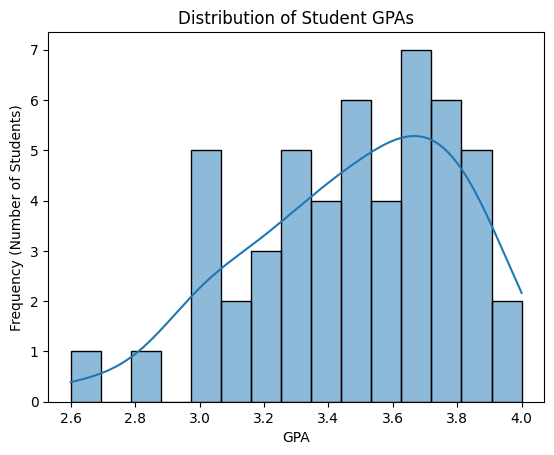

In [15]:
plt.figure()
sns.histplot(student_eating_survey['GPA'], bins=15, kde=True)
plt.title('Distribution of Student GPAs')
plt.xlabel('GPA')
plt.ylabel('Frequency (Number of Students)')
plt.show()

This histogram shows that majority of the students who took this survey had a GPA of 3.0 and above. This could make our findings difficult to generalize to a population of students of all GPAs including lower GPAs.

### **B. Investigating a relationship between family income and the likelihood of consuming fruits and vegetables.**

*Hypothesis:*


Before studying the relationship between family income and the likelihood of consuming fruits, our team reviewed the variables ('income' and 'fruit_day') that we would be utilizing. Both are categorical variables that utilize label encoding.

In [16]:
display(refer_to.iloc[31, :])

NameError: name 'refer_to' is not defined

This variable, family income, is split into 6 categories coded by a number 1-6:
* 1: less than \$15,000
* 2: \$15,001-\$30,000
* 3: \$30,001 to \$50,000
* 4: \$50,001-\$70,000
* 5: \$70,001-\$100,000
* 6: higher than \$100,000

In [ ]:
display(refer_to.iloc[24, :])

This variable, fruit_day, represents how likely the survey respondents were to eat any fruit in a regular day. Their likeliness was coded into 5 numerical options:
* 1: very unlikely
* 2: unlikely
* 3: neutral
* 4: likely
* 5: very likely

In [13]:
student_eating_survey.groupby('income')['fruit_day'].mean()

,fruit_day
income,
2,5.000000
3,4.250000
4,4.333333
5,4.666667
6,4.090909


First, we calculated the mean likelihood of consuming fruit per income group. All income groups achieved a score of 4 or higher: A 4-5 score is associated with "likely"-"very likely". All income groups were atleast likely to consume fruit in a day. It is important to notice the perfect score of 5 for income group 2 (ranging from \$15,001-\$30,000) came from one individual. Additionally, there does not appear to be a clear positive or negative relationship.

/tmp/ipykernel_1235/3720213793.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot1.set_xticklabels(income_labels)


[Text(0, 0, '<$15k'),
 Text(1, 0, '$15k-30k'),
 Text(2, 0, '$30k-50k'),
 Text(3, 0, '$50k-70k'),
 Text(4, 0, '$70k-100k'),
 Text(5, 0, '>$100k')]

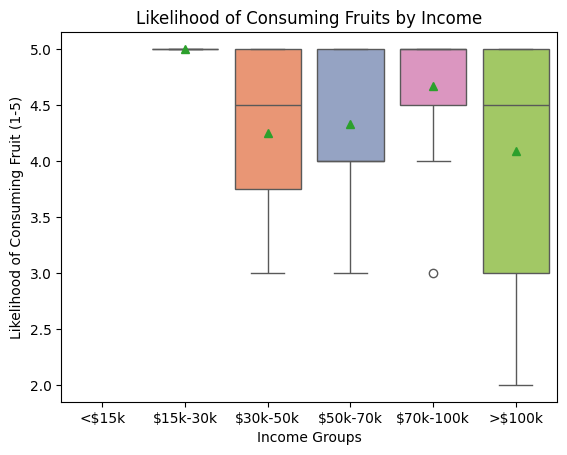

In [20]:
income_labels = ['<$15k', '$15k-30k', '$30k-50k', '$50k-70k', '$70k-100k', '>$100k']
boxplot1 = sns.boxplot(data=student_eating_survey, x='income', y='fruit_day', showmeans=True,
                       hue='income', palette="Set2", legend=False, order=[1,2,3,4,5,6])
boxplot1.set_title('Likelihood of Consuming Fruits by Income')
boxplot1.set_ylabel('Likelihood of Consuming Fruit (1-5)')
boxplot1.set_xlabel('Income Groups')
boxplot1.set_xticklabels(income_labels)






Plotting a boxplot of the likelihood of consuming fruit per income group allowed our team to visualize the variance within each group. The lack of "box" in boxplot representing income group 2 demonstrates the singular observation. There is a slight positive relationship between income groups three through five, indicating that the increase in income may correlate with a greater likelihood of consuming fruit.

In [ ]:
display(refer_to.iloc[51, :])

This variable, veggies_day, represents how likely the survey respondents were to eat any vegetables in a regular day. Their likeliness was coded into 5 numerical options:
* 1: very unlikely
* 2: unlikely
* 3: neutral
* 4: likely
* 5: very likely

Now we will transition to study the relationship between family income and the likelihood of consuming vegetables. We will use both 'veggies_day' and 'income'. Both are categorical variables that utilize label encoding.

In [ ]:
student_eating_survey.groupby('income')[['veggies_day']].mean()

First, we calculated the mean likelihood of consuming vegetables per income group. Once again, there appears to be no consistent relationship between the variables.

Compared to the mean likelihood of consuming fruits (per income group), the mean likelihood of consuming vegetables (per income group) seemed smaller. All income groups achieved a mean likelihood of consuming fruits of 4 or higher, but only three income groups achieved a mean likelihood of consuming fruits of 4 or higher.

/tmp/ipykernel_1235/1883077912.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  boxplot2.set_xticklabels(income_labels)


[Text(0, 0, '<$15k'),
 Text(1, 0, '$15k-30k'),
 Text(2, 0, '$30k-50k'),
 Text(3, 0, '$50k-70k'),
 Text(4, 0, '$70k-100k'),
 Text(5, 0, '>$100k')]

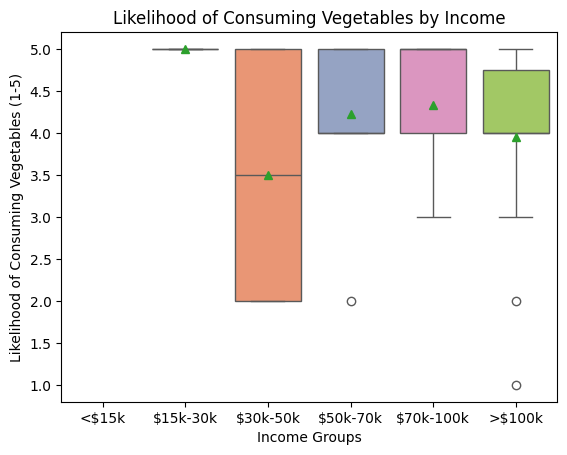

In [23]:
income_labels = ['<$15k', '$15k-30k', '$30k-50k', '$50k-70k', '$70k-100k', '>$100k']
boxplot2 = sns.boxplot(data=student_eating_survey, x='income', y='veggies_day',
                       showmeans=True, hue='income', palette="Set2", legend=False, order=[1,2,3,4,5,6])
boxplot2.set_title('Likelihood of Consuming Vegetables by Income')
boxplot2.set_ylabel('Likelihood of Consuming Vegetables (1-5)')
boxplot2.set_xlabel('Income Groups')
boxplot2.set_xticklabels(income_labels)

After plotting a boxplot that visualizes the likelihood of consuming vegetables per income group, our group can see the spread between groups. Our team observed that there were more outliers in this subset of data; outliers may influence the mean by pulling it higher or lower based on their value. This is apparent in income groups 4 and 6 where the sample mean could be valued higher without the outliers. We also noticed that income group 3 had the greatest spread among all income groups. There appears to be no overall relationship between the likelihood of consuming vegetables per income group. But also it is important to notice the slight positive relationship between income groups 3 to 5.

### **C. Exploring how working status may influence a student’s likelihood to consume fruit and vegetables**

---


In [ ]:
display(refer_to.iloc[14, :])

This variable, employment, codes the survyees employment status into 4 numbers:
* 1: full time
* 2: part time
* 3: unemployed
* 4: other

Now we will study the relationship between work status and the likelihood of consuming fruits. We will use both 'fruits_day' and 'employment'. Both are categorical variables that utilize label encoding.

In [ ]:
student_eating_survey.groupby('employment')['fruit_day'].mean()

After calculating the mean likelihood of consuming fruit per income group, our team noticed that all employment statuses achieved a mean likelihood of consuming fruit of 4 and greater. We noticed that the full-time employed students also achieved a greater mean compared to part-time employed students. Comparing the means between part-time employed students versus unemployed students, our team noticed a greater mean likelihood of consuming fruits for unemployed students. However, our group has suspicions about the perfect "5" score being one singular observation again.  

In [ ]:
boxplot4 = sns.boxplot(data=student_eating_survey, x='employment', y='fruit_day', showmeans=True, hue='employment', palette="Set2")
boxplot4.set_title('Likelihood of Consuming Fruits by Employment Status')
boxplot4.set_ylabel('Likelihood of Consuming Fruits (1-5)')
boxplot4.set_xlabel('Employment Status')
plt.legend(title="Employment Status", loc='lower left')

From this boxplot, we are able to compare the variances of likeliness of consuming fruits per employment status. We observed that the greatest variance was from part-time student workers, which ranged from scores 2 to 5. There seems to be one observation for a full-time student worker. Our theory from earlier is demonstrated above where our team noticed a greater mean likelihood of consuming fruits for unemployed students compared to the mean likelihood of consuming fruits for part-time employed students.

In [ ]:
student_eating_survey.groupby('employment')['veggies_day'].mean()

If we only compare employed students versus unemployed students, unemployed students achieve a greater mean likelihood of consuming veggies.

In [ ]:
boxplot3 = sns.boxplot(data=student_eating_survey, x='employment', y='veggies_day', hue='employment', palette="Set2")
boxplot3.set_title('Likelihood of Consuming Vegetables by Employment Status')
boxplot3.set_ylabel('Likelihood of Consuming Vegetables (1-5)')
boxplot3.set_xlabel('Employment Status')
plt.legend(['1:Yes, Full Time','2: Yes, Part Time', '3: No'])

From this boxplot, we observed the greatest variance was from part-time student workers, which ranged from scores 2 to 5, which was similar to Likelihood of Consuming Fruits by Employment Status plot. Additionally, there are more outliers like the Likelihood of Consuming Vegetables by Income Group plot.

### **D. Determine whether health status and GPA are correlated.**


To quantify health status, we will be using the column healthy_feeling. Students answered a statement "I feel very healthy!" with a number in a range from 1-10, with 1 being "strongly disagree" and 10 being "strongly agree".

First, let's see how many college students from this data set perceive themselves to be healthy. We will count "unhealthy" as students who answered 1-5 and "healthy" as students who answered 6-10.

In [ ]:
healthy_students = student_eating_survey[student_eating_survey['healthy_feeling']>5]
unhealthy_students = student_eating_survey[student_eating_survey['healthy_feeling']<6]
count_healthy = healthy_students['GPA'].count()
count_unhealthy = unhealthy_students['GPA'].count()
plt.figure()
sns.barplot(x=['Healthy','Unhealthy'],y=[count_healthy,count_unhealthy])
plt.ylabel('Number of Students')
plt.title('Count of Healthy vs. Unhealthy Students')
plt.show()
print("\n")
print("# of Healthy Students: " + str(healthy_students['GPA'].count()))
print("# of Unhealthy Students: " + str(unhealthy_students['GPA'].count()))

We can see that more students considered themselves to be unhealthy than healthy.

Next, let's make a simple scatterplot of the raw data.

In [ ]:
x_healthiness = student_eating_survey['healthy_feeling']
y_GPA = student_eating_survey['GPA']
plt.scatter(x_healthiness,y_GPA)

This plot has no labels and overlapping data points. There is no clear relationship between x and y.

In [ ]:
healthiness_labels = ['I feel very \n unhealthy',2,3,4,5,6,7,8,9,'I feel very \n healthy!']
plt.figure()
sns.swarmplot(x=x_healthiness, y=y_GPA, hue=x_healthiness, palette='colorblind', legend=False)
plt.title('GPA Distribution per Health Category')
plt.xlabel('Health Feeling Category (1-10)')
plt.xticks(ticks=[0,1,2,3,4,5,6,7,8,9],labels=healthiness_labels, rotation=25)
plt.show()

Here is an improved scatterplot, or rather, a swarmplot (categorical scatterplot) by seaborn. Here, we can see the overlapping data points and we have labels, so we know what data we are looking at. We still can't exactly see any patterns in the data and we can see that not all categories have the same sample size.

In [ ]:
health_cat_samplesizes = student_eating_survey.groupby('healthy_feeling')['GPA'].count()
health_cat_samplesizes

Most of the health feeling categories have 5-8 data points, while category 10 only has 2 data points and category 7 only has 1. Since there is not multiple data points for category 7, it will be hard to use this category to generalize our findings of this relationship between a person's feeling of healthiness and GPA to a larger population. Although categories 7 & 10 have incredibly small sample size, its important to note that a sample size of 5-8 is not great either.

In [ ]:
health_cat_means = student_eating_survey.groupby('healthy_feeling')['GPA'].mean()
health_cat_means

Since we couldn't see any patterns or relationships in the raw data, it is relevant to calculate the means to see if there is a pattern there. The mean of category 7 is the smallest (although this mean comes from only 1 data point) and the mean of category 1 is the largest.

In [ ]:
z = np.polyfit(x_healthiness,y_GPA,1)
p = np.poly1d(z)
plt.figure()
plt.scatter(x=health_cat_means.index, y=health_cat_means.values)
plt.title('Healthy Feeling Category Means')
plt.xticks(ticks=[1,2,3,4,5,6,7,8,9,10], labels=healthiness_labels)
plt.xlabel('Health Feeling Category')
plt.ylabel('GPA')
plt.plot(x_healthiness,p(x_healthiness))

Here, I plotted the means and fitted a line. The mean dots alone curve down and up and down and up, but when we fit a line, we can see that there is a general downward trend.

In [ ]:
plt.figure()
sns.boxplot(x=x_healthiness, y=y_GPA, hue=x_healthiness, palette='colorblind', legend=False)
plt.xticks(ticks=[0,1,2,3,4,5,6,7,8,9],labels=healthiness_labels)
plt.title('Distribution of GPA by Health Feeling Category')
plt.xlabel('Health Feeling Category')
plt.show()

This boxplot displays the varying means of this data that don't have a clear shape, the different sample sizes and variances of each category with the box, whiskers, and mean line of category 7 being the same line, and the wide boxes and whiskers that most of the other categories have. Although when we plotted the means with a fitted line, we saw that there was a slight downward trend, we can see with this boxplot that there is so much variation in the data/such a wide range of GPAs per category that those means may not show a true pattern.

### **E. Assess the relationship between family income and GPA.**

For this question, we will use the columns "income" and "GPA". Again, income is an interval variable with a range from 1-6 where 1 represents a family income of <\\$15,000, 2 represents a family income of \\$15,001-\\$30,000, 3 represents a family income of \\$30,001-\\$50,000, 4 represents a family income of \\$50,001-\\$70,000, 5 represents a family income of \\$70,001-\\$100,000, and 6 represents a family income of >\\$100,001. GPA is an open-ended, float variable with a range from 0.0-4.0.

First, we can make a simple scatterplot of the raw data.

In [ ]:
x_income = student_eating_survey['income']
y_GPA = student_eating_survey['GPA']
plt.scatter(x_income,y_GPA)

This scatterplot made it seem like there was only ~30 data points when the data set actually contains 51. The x-axis was also formatted weirdly. There are 6 categories of family income level in the dataset, but the axis labels were 2.0-6.0 at intervals of 0.5. This graph shows no obvious relationship between GPA and family income, however, there is very inconsistent variance across the income categories.

In [ ]:
plt.figure()
sns.swarmplot(x=x_income, y=y_GPA, hue=x_income, palette='colorblind', legend=False,
              order=[1,2,3,4,5,6])
plt.title('GPA Distribution per Income Category')
plt.xlabel('Income Category (1-6)')
plt.show()

This plot looks much better than our first plot as we have, using the seaborn package, jittered the data points, so we can see the overlapping ones, we have added axis labels and a title, and we have colored the points for visual appeal. We also added an axis label for Income Category 1 since it was one of the options in the survey, although it didn't apply to any respondents so we don't have any data for it.

In [ ]:
income_labels = ['<$15k', '$15k-30k', '$30k-50k', '$50k-70k', '$70k-100k', '>$100k']
plt.figure()
sns.swarmplot(x=x_income, y=y_GPA, hue=x_income, palette='colorblind', legend=False, order=[1,2,3,4,5,6])
plt.title('GPA Distribution per Income Category')
plt.xlabel('Family Income Range')
plt.xticks(ticks=[0, 1, 2, 3, 4, 5], labels=income_labels)
plt.show()

To make it clearer for those who aren't familar with this dataset, the only thing I changed with this scatter plot is that I simply relabeled the income categories with the income levels that they represent.

In [ ]:
plt.figure()
sns.barplot(x=x_income, y=y_GPA, hue=x_income, palette='colorblind', legend=False, order=[1,2,3,4,5,6], errorbar=None)
plt.xticks(ticks=[0,1,2,3,4,5], labels=income_labels)
plt.title('Average GPA by Income Category')
plt.xlabel('Family Income Range')
plt.show()

This chart shows the mean GPAs for each income category. We can see that all 5 of these look pretty similar as all averages are around 3.5. This plot doesn't show any indications of a relationship between income and GPA.

In [ ]:
income_cat_means = student_eating_survey.groupby('income')['GPA'].mean()
income_cat_means

Since the average GPAs in the barplot were too close together to be able to see any differences between them or any patterns, it is relevant to simply compute the means. Here we can still see that the average GPAs per category are no more than 0.2 GPA points apart from each other, but we do see a slight upside-down U shape. There does not seem to be a positive or negative linear relationship to these means, there is a slight curve.

In [ ]:
plt.figure()
sns.barplot(x=x_income, y=y_GPA, order=[1,2,3,4,5,6], errorbar=None)
sns.swarmplot(x=x_income, y=y_GPA, color='red')
plt.xticks(ticks=[0,1,2,3,4,5], labels=income_labels)
plt.title('Average GPA (Bars) vs. Individual Student GPA (Dots)')
plt.xlabel('Family Income Range')
plt.show()

Here I made a plot combining the scatterplot of the data and the boxplot of the category means from above, just to see this data in one place.

In [ ]:
plt.figure()
sns.boxplot(x=x_income, y=y_GPA, hue=x_income, palette='colorblind', legend=False, order=[1,2,3,4,5,6])
plt.xticks(ticks=[0,1,2,3,4,5], labels=income_labels)
plt.title('Distribution of GPA by Income Category')
plt.xlabel('Family Income Range')
plt.show()

This boxplot is probably the best visualization tool for this data. It shows the means per category as well as the spread of the data and outlier data points. This chart shows that although the means are similar, the amount of data in each category varies widely which may make it difficult to interpret any patterns from these results. Income category 1 has only one data point so the mean line, box, and whiskers are all the same line. Income categories 5 & 6 have much larger box widths and whisker lengths than categories 3 & 4, showing larger spread. From this data, we do not see any clear relationship between family income and GPA, but if we had more data, we may have been able to detect a pattern.

In [ ]:
income_cat_samplesizes = student_eating_survey['income'].value_counts().sort_values(ascending=True)
income_cat_samplesizes

Using value_counts(), we can see the differences in sample size per income category that will make it difficult to determine patterns from this data. Maybe if the survey had had participants list their exact family income instead of selecting an income range, we could've derived more meaningful results from this data.

### **F. Overall Analyses**

In this phase of the project, we examined multiple variables—including income, health, and academic performance—by calculating group means and analyzing the relationships among these variables, along with their respective variances.

After plotting the boxplot, it was easier to identify patterns. From past statistics courses, our group understood there was a relationship present if the group means followed a curve (ie. linear, exponential, logarithmic, etc.) or the difference between means were substantial. However, almost all boxplots either had similar group means or were randomly scattered. It was interesting to see our hypothesis performed against real world data. One potential explanation for the lack of correlation could be due to the limited sample. While there were 51 respondents in this dataset, the method used to collect the data is unclear. If surveyors relied on data from self-selected volunteers, this dataset may suffer from voluntary response bias. This dataset may overrepresent certain group of individuals rather than accurately reflecting the general population. It would be interesting to conduct additional analyses across multiple trials.

One plot demonstrated a negative linear trend. This plot compared academic performance to how healthy respondents felt. We were surprised to see a negative association, instead we expected that students feeling more healthy would achieve greater academic performance. We believed that healthier students would be more motivated academically. On another hand, it’s also true that individuals may risk their health to achieve higher grades. Maintaining “good health” can require a significant time commitment such as meal prepping, working out, and engaging in mindful activities. Students with limited time may skip meals, substitute fast food for healthy alternatives, consume highly-caffeinated drinks to sustain energy, neglect rest and exercise.


### Part 2: Affordability of Maintaining a Healthy Diet

---



To address the affordability of maintaining a healthy personal diet, our team will be using [reports](https://www.ers.usda.gov/data-products/fruit-and-vegetable-prices) from the
USDA, Economic Research Service. These reports provide the average retail price for 300 fruits
and vegetables. Our team will utilize the variable, AveragePricePerCupEquivalent, to calculate
the cost of eating the recommended serving size of fruits and vegetables according to MyPlate.

**A. Data Cleaning & Exploration**

In [ ]:
fruity = pd.read_csv('fruit-prices-2023.csv')
fruity.head()

In [ ]:
veggie = pd.read_csv('vegetable-prices-2023.csv')
veggie.head()

**B.  Estimating the cost per serving of fruit**

In [ ]:
# calculate the average price per cup for all fruits
avgcostf = fruity['AveragePricePerCupEquivalent'].mean()
display(avgcostf)

In [ ]:
fruity.pivot_table('AveragePricePerCupEquivalent', index='Form')

In [ ]:
# calculate the cost of consuming 1.5 cups of fruit
fdailyprice1 = avgcostf * 1.5
display(fdailyprice1)

# calculate the cost of consuming 2 cups of fruit
fdailyprice2 = avgcostf * 2
display(fdailyprice2)

In [ ]:
# calculate the cost of consuming the recommended portion size monthly
monthlyprice1 = fdailyprice1 * 30
display(monthlyprice1)

monthlyprice2 = fdailyprice2 * 30
display(monthlyprice2)

According to [MyPlate](https://https://www.myplate.gov/), it is recommended to eat 1.5 to 2 cups of fruit per day.

**C. Estimating the cost per serving of vegetables**

In [ ]:
# calculate the average price per cup for all fruits
avgcostv = veggie['AveragePricePerCupEquivalent'].mean()
display(avgcostv)

In [ ]:
veggie.pivot_table('AveragePricePerCupEquivalent', index='Form')

In [ ]:
# calculate the cost of consuming 2 cups of vegetables
vdailyprice1 = avgcostv * 2
display(vdailyprice1)

# calculate the cost of consuming 3 cups of vegetables
vdailyprice2 = avgcostv * 3
display(vdailyprice2)

In [ ]:
# calculate the cost of consuming the recommended portion size monthly
monthlyprice1v = vdailyprice1 * 30
display(monthlyprice1v)

monthlyprice2v = vdailyprice2 * 30
display(monthlyprice2v)

**D. Overall Analyses**

### Conclusion